In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
from scipy.stats import wasserstein_distance  
from scipy.stats import norm

T = 20
time_steps = np.arange(T)
n_normals = 100
n_radicals = 3
bins = 100
opinion_bins = np.arange(1, bins+1)
bin_edges = np.linspace(0, 1, bins+1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
beta = 10
alpha = 0.1
epsilon = 0.1
radical_weight = 30
seed_value = 20
rng = np.random.default_rng(seed=seed_value)
initial_opinions = np.clip(rng.normal(loc=0.4, scale=0.2, size=n_normals), 0, 1)

def phi(diff, beta):
    return 1 / (1 + np.exp(beta * (abs(diff)-epsilon)))

def simulate_continuous_model(radicals, n_normals, n_radicals, T):
    radicals = np.array(radicals).reshape((T, n_radicals))
    opinions = initial_opinions
    historique = [opinions.copy()]
    for t in range(T):
        rads = radicals[t]
        total_opinions = np.concatenate([opinions, rads])
        updated_opinions = np.copy(opinions)
        for i in range(n_normals):
            xi = opinions[i]
            xj = total_opinions
            influence_weights = phi(xi - xj, beta)
            influence_weights[i] = 0 
            influence_weights[-n_radicals:] *= radical_weight
            sum_weights = np.sum(influence_weights)
            if sum_weights > 0:
                influence = np.sum(influence_weights * (xj - xi)) / sum_weights
                updated_opinions[i] = xi + alpha * influence
        opinions = np.clip(updated_opinions, 0, 1)
        historique.append(opinions.copy())
    return opinions, np.array(historique)


#def wasserstein(n_normals, n_radicals, T, target_dist):
    def cost(u):
        final_opinions = simulate_continuous_model(u, n_normals, n_radicals, T)
        return wasserstein_distance(
            final_opinions,
            np.random.choice(bin_centers, size=len(final_opinions), p=target_dist)
        )
    return cost

def cost(radicals ,n_normals, n_radicals, T):
    final_opinions = simulate_continuous_model(radicals, n_normals, n_radicals, T)[0]
    cost = -np.sum(final_opinions)
    return cost

bounds = [(0, 1)] * (T * n_radicals)
result = differential_evolution(cost, bounds, maxiter=40, args=(n_normals, n_radicals, T))
radicals = result.x.reshape((T, n_radicals))



[[0.63140901]
 [0.63448059]
 [0.63626965]
 [0.63854686]
 [0.64112159]
 [0.64255991]
 [0.6445641 ]
 [0.644098  ]
 [0.644715  ]
 [0.64482276]
 [0.64533567]
 [0.644394  ]
 [0.64433576]
 [0.64417036]
 [0.64253587]
 [0.64200982]
 [0.63995375]
 [0.63914748]
 [0.63840678]
 [0.63769976]]


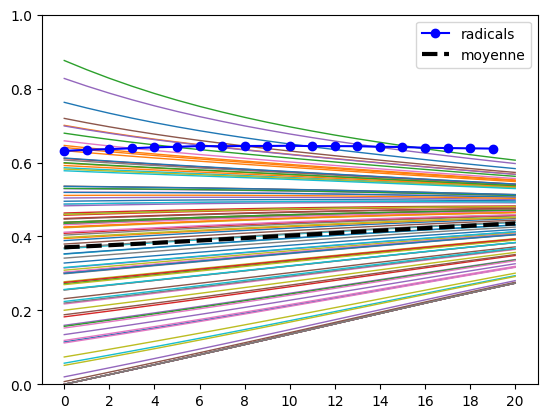

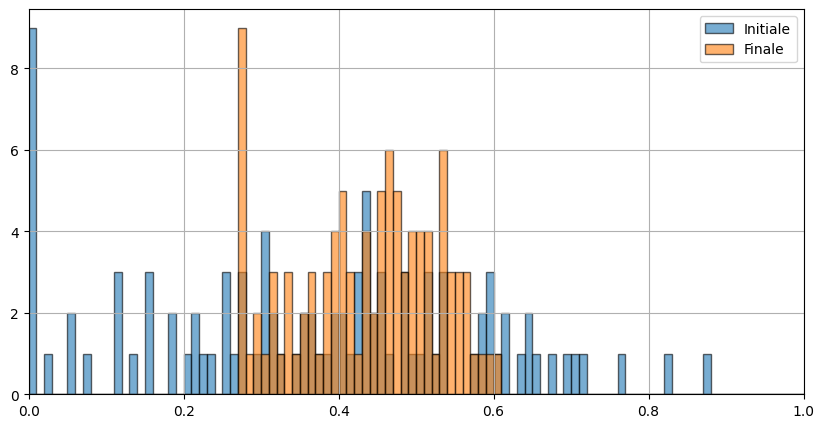

In [5]:
final_opinions = simulate_continuous_model(result.x, n_normals, n_radicals, T)[0]

print(radicals)

def historique():
    historique =simulate_continuous_model(result.x, n_normals, n_radicals, T)[1]
    for agent in range(n_normals):
        plt.plot(historique[:, agent],alpha=1, linewidth=1)
    radicals_optimal = np.sort(radicals)
    radical_opinions_over_time = radicals_optimal[:, 0]
    plt.plot(time_steps, radical_opinions_over_time, marker='o', linestyle='-', color = 'blue', label = 'radicals')
    for i in range(1,n_radicals):
        radical_opinions_over_time = radicals_optimal[:, i]
        plt.plot(time_steps, radical_opinions_over_time, marker='o', linestyle='-', color = 'blue')
    moyenne = np.mean(historique, axis=1)
    plt.plot(moyenne, color='black',linestyle='--', linewidth=3, label = 'moyenne')
    plt.ylim(0, 1)
    plt.xticks(np.arange(0, T + 1, 2))
    plt.legend()
    plt.show()
historique()

plt.figure(figsize=(10, 5))
plt.hist(initial_opinions, bins=bin_edges, alpha=0.6, label="Initiale", edgecolor='black', density=True)
plt.hist(final_opinions, bins=bin_edges, alpha=0.6, label="Finale", edgecolor='black', density=True)

plt.legend()
plt.xlim(0, 1)
plt.grid(True)
plt.show()